In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**Dataset utilizado**
- El dataset elegido para este proyecto es 'Formula 1 World Championship (1950 - 2024)' el cual consiste de información de carreras, pilotos, escuderias, qualis, cicuitos, tiempos de vuelta, etc. de los campeonatos desde 1950 hasta 2024.

In [2]:
circuits = pd.read_csv('/content/circuits.csv')
constructors = pd.read_csv('/content/constructors.csv')
drivers = pd.read_csv('/content/drivers.csv')
races = pd.read_csv('/content/races.csv')
results = pd.read_csv('/content/results.csv')

print(f'circuits: {circuits.shape}')
print(f'constructors: {constructors.shape}')
print(f'drivers: {drivers.shape}')
print(f'races: {races.shape}')
print(f'results: {results.shape}')

circuits: (77, 9)
constructors: (212, 5)
drivers: (861, 9)
races: (1125, 18)
results: (26759, 18)


In [3]:
# Selección de columnas de interés de cada set de datos
results_selected = results[
    [
        "raceId",
        "driverId",
        "constructorId",
        "grid",
        "positionOrder",
        "points",
        "laps",
        "statusId"
    ]
]

races_selected = races[
    [
        "raceId",
        "year",
        "round",
        "circuitId"
    ]
]

drivers_selected = drivers[
    [
        "driverId",
        "driverRef",
        "nationality"
    ]
]

constructors_selected = constructors[
    [
        "constructorId",
        "constructorRef"
    ]
]

circuits_selected = circuits[
    [
        "circuitId",
        "circuitRef",
        "country"
    ]
]

In [4]:
# Merge datasets utilizando las llaves primarias
df = results_selected.merge(races_selected, on="raceId", how="left")
df = df.merge(drivers_selected, on="driverId", how="left")
df = df.merge(constructors_selected, on="constructorId", how="left")
df = df.merge(circuits_selected, on="circuitId", how="left")


print("\nMerged dataset shape:", df.shape)
print(df.head())


Merged dataset shape: (26759, 16)
   raceId  driverId  constructorId  grid  positionOrder  points  laps  \
0      18         1              1     1              1    10.0    58   
1      18         2              2     5              2     8.0    58   
2      18         3              3     7              3     6.0    58   
3      18         4              4    11              4     5.0    58   
4      18         5              1     3              5     4.0    58   

   statusId  year  round  circuitId   driverRef nationality constructorRef  \
0         1  2008      1          1    hamilton     British        mclaren   
1         1  2008      1          1    heidfeld      German     bmw_sauber   
2         1  2008      1          1     rosberg      German       williams   
3         1  2008      1          1      alonso     Spanish        renault   
4         1  2008      1          1  kovalainen     Finnish        mclaren   

    circuitRef    country  
0  albert_park  Australia  
1

In [5]:
# check nulls
print(df.isnull().sum())

raceId            0
driverId          0
constructorId     0
grid              0
positionOrder     0
points            0
laps              0
statusId          0
year              0
round             0
circuitId         0
driverRef         0
nationality       0
constructorRef    0
circuitRef        0
country           0
dtype: int64


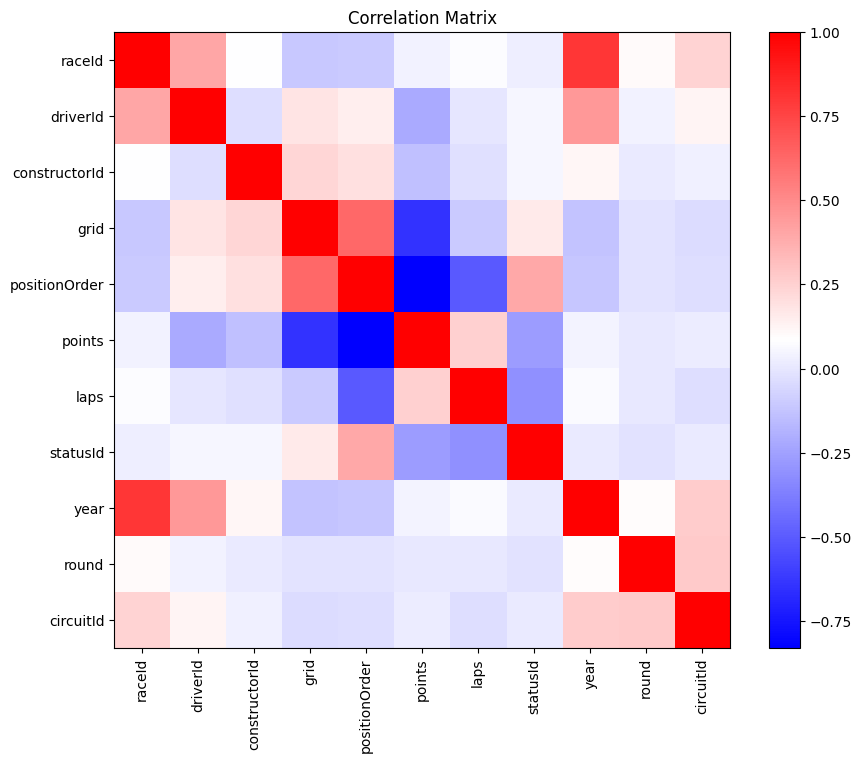

In [39]:
corr_matrix = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='bwr', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

## Filtro temporal

Se decidió utilizar datos desde el año 2010 hasta 2024 para reducir variaciones históricas en reglas, sistemas de puntuación y cambios técnicos de la Fórmula 1. Esta decisión también se alinea con el paper base, el cual trabaja con datos recientes para mantener mayor consistencia en el análisis.

In [6]:
# discard non-qualified, started from pit, disqualified drivers
df = df[df["grid"] > 0]

# use data since 2010
df = df[df["year"] >= 2010]

print("\nMerged dataset shape:", df.shape)
print(f"Dataset: {len(df):,} registros")
print(f"   Años: {df['year'].min()}-{df['year'].max()}")


Merged dataset shape: (6351, 16)
Dataset: 6,351 registros
   Años: 2010-2024


## Variable objetivo

La variable objetivo del proyecto es `positionOrder`, la cual representa la posición final obtenida por un piloto en una carrera.

El problema se plantea como una tarea de regresión, ya que se busca predecir un valor numérico correspondiente a la posición final.

In [19]:
# elegir columna a predecir y features
target_column = "positionOrder"

features = [
    "year",
    "round",
    "grid",
    "driverRef",
    "constructorRef",
    "circuitRef",
    "country"
]

X = df[features]
y = df[target_column]

In [29]:
# normalizar columnas categóricas
categorical_columns = [
    "driverRef",
    "constructorRef",
    "circuitRef",
    "country"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [9]:
# definir split train/test 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



Train/Test split:
X_train: (5080, 197)
X_test: (1271, 197)
y_train: (5080,)
y_test: (1271,)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [11]:
train_data = X_train_scaled_df.copy()
train_data[target_column] = y_train.reset_index(drop=True)

test_data = X_test_scaled_df.copy()
test_data[target_column] = y_test.reset_index(drop=True)

print("\nTrain/Test split:")
print("train_data:", train_data.shape)
print("test_data:", test_data.shape)


Train/Test split:
train_data: (5080, 198)
test_data: (1271, 198)


In [26]:
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=train_data.shape[1] - 1))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

history = model.fit(
    train_data.drop(target_column, axis=1),
    train_data[target_column],
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 72.5267 - mae: 6.5500 - val_loss: 17.2485 - val_mae: 3.2475
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.3081 - mae: 2.7736 - val_loss: 9.5979 - val_mae: 2.4397
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.1753 - mae: 2.1716 - val_loss: 7.1708 - val_mae: 2.0349
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0459 - mae: 1.8211 - val_loss: 5.9731 - val_mae: 1.8713
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.9515 - mae: 1.6659 - val_loss: 5.8775 - val_mae: 1.8251
Epoch 6/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3357 - mae: 1.5625 - val_loss: 5.3933 - val_mae: 1.7865
Epoch 7/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9111 - mae: 1.4812 - val_loss: 5.3385 - val_mae: 1.7207
Epoch 8/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.5834 - mae: 1.4085 - val_loss: 5.0066 - val_mae: 1.6932
Epoch 9/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.31

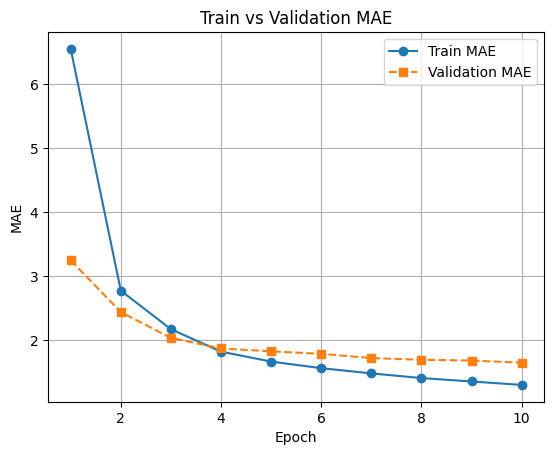

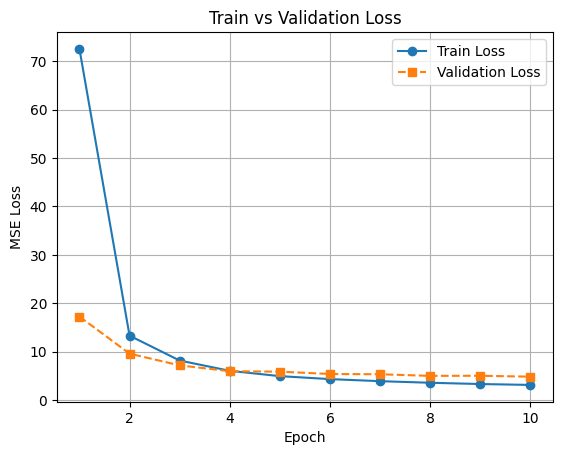

In [28]:
mae_train = history.history["mae"]
loss_train = history.history["loss"]
mae_val = history.history["val_mae"]
loss_val = history.history["val_loss"]

epochs = range(1, len(mae_train) + 1)

plt.figure()
plt.plot(epochs, mae_train, "o-", label="Train MAE")
plt.plot(epochs, mae_val, "s--", label="Validation MAE")
plt.title("Train vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, loss_train, "o-", label="Train Loss")
plt.plot(epochs, loss_val, "s--", label="Validation Loss")
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
X_test_final = test_data.drop(target_column, axis=1)
y_test_final = test_data[target_column]

y_pred = model.predict(X_test_final).flatten()

mae = mean_absolute_error(y_test_final, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred))
r2 = r2_score(y_test_final, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE: 1.5394445657730103
RMSE: 2.135226493989231
R²: 0.8771518468856812


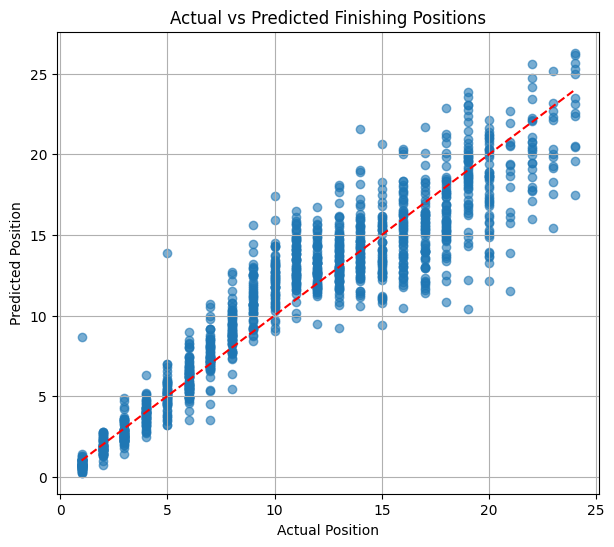

In [34]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="red"
)
plt.title("Actual vs Predicted Finishing Positions")
plt.xlabel("Actual Position")
plt.ylabel("Predicted Position")
plt.grid(True)
plt.show()

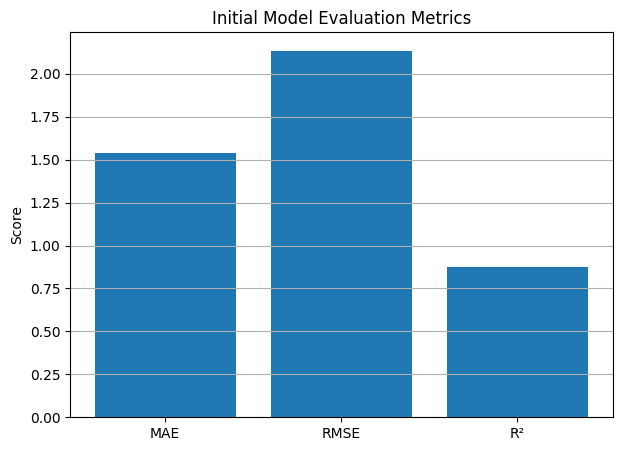

In [33]:
metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2
}

plt.figure()
plt.bar(metrics.keys(), metrics.values())
plt.title("Initial Model Evaluation Metrics")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()